In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
import plotly.express as px

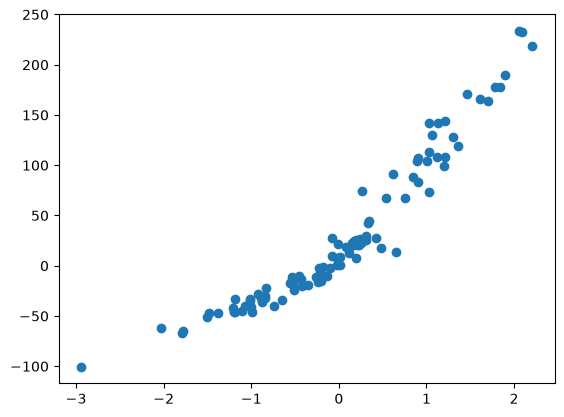

In [2]:
x, y = make_regression(n_samples=100, n_features=1, noise=10)

y = y + abs(y/2)
plt.scatter(x, y)

In [3]:
print(x.shape, y.shape)

(100, 1) (100,)


In [4]:
y = y.reshape(y.shape[0], 1)  # Reshape y to be a column vector

In [5]:
# matrice X
X = np.hstack((x, np.ones(x.shape)))
X = np.hstack((x**2, X))  # Add a column of ones for the intercept term and a column for x^2

print(x.shape, y.shape, X.shape)

(100, 1) (100, 1) (100, 3)


In [6]:
theta = np.random.randn(3, 1)  # Random initialization of theta
theta.shape

(3, 1)

In [7]:
def model(X, theta):
    return X.dot(theta)

model(X, theta)

array([[2.00398749],
       [2.25139303],
       [3.21334828],
       [2.54401954],
       [2.14162562],
       [2.39685545],
       [2.12909949],
       [2.03419055],
       [4.27451692],
       [2.2328209 ],
       [3.25868251],
       [2.03046436],
       [2.7379981 ],
       [2.98375802],
       [2.17602474],
       [2.01573834],
       [2.65292349],
       [3.03097432],
       [2.19833618],
       [2.0170693 ],
       [2.12333802],
       [3.62765018],
       [2.63402608],
       [2.37371165],
       [2.11902861],
       [2.30294628],
       [2.2456316 ],
       [2.09027343],
       [2.01738846],
       [2.83117789],
       [2.12320838],
       [2.99814021],
       [1.99629614],
       [2.0046902 ],
       [2.16799571],
       [4.70761567],
       [2.15414869],
       [2.09778103],
       [2.37278383],
       [2.08506908],
       [2.00012532],
       [2.25266078],
       [2.4542573 ],
       [2.64152989],
       [3.13253045],
       [3.11732411],
       [1.99664302],
       [2.538

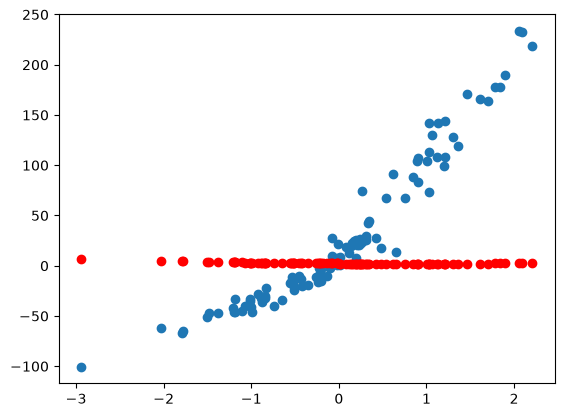

In [8]:
plt.scatter(x, y)
plt.scatter(x, model(X, theta), color='red')

In [9]:
def cost_function(X, y, theta):
    m = len(y)
    predictions = model(X, theta)
    cost = (1/(2*m)) * np.sum(np.square(predictions - y))
    return cost

In [10]:
cost_function(X, y, theta)

np.float64(3176.977100844852)

In [11]:
def grad(X, y, theta):
    m = len(y)
    return (1/m) * X.T.dot(model(X, theta) - y)

In [12]:
def gradient_descent(X, y, theta, learning_rate=0.01, iterations=1000):
    cost_history = np.zeros(iterations)
    for i in range(iterations):
        theta -= learning_rate * grad(X, y, theta)
        cost_history[i] = cost_function(X, y, theta)

    return theta, cost_history

In [13]:
theta_final, cost_history = gradient_descent(X, y, theta, learning_rate=0.01, iterations=500)

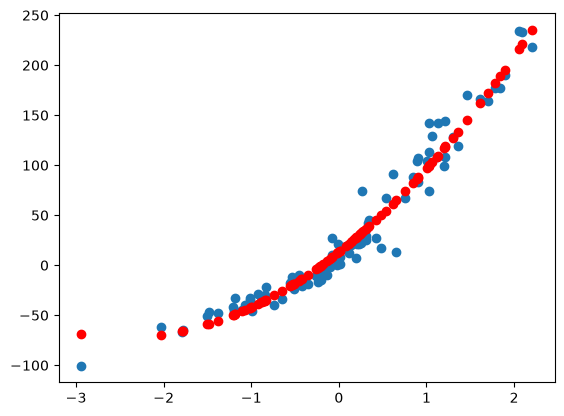

In [14]:
plt.scatter(x, y)
plt.scatter(x, model(X, theta_final), color='red')

In [15]:
theta_final

array([[14.15040052],
       [69.50224296],
       [13.37890162]])

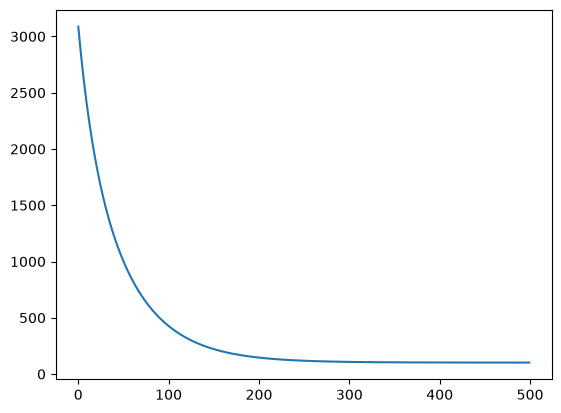

In [16]:
plt.plot(cost_history)

In [17]:
def coef_deter(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    return 1 - (ss_res / ss_tot)

predictions = model(X, theta_final)
r_squared = coef_deter(y, predictions)
r_squared


np.float64(0.9631403444073688)

In [18]:
cost = cost_function(X, y, theta)
cost

np.float64(102.00387738721463)

# Avec plusieurs features

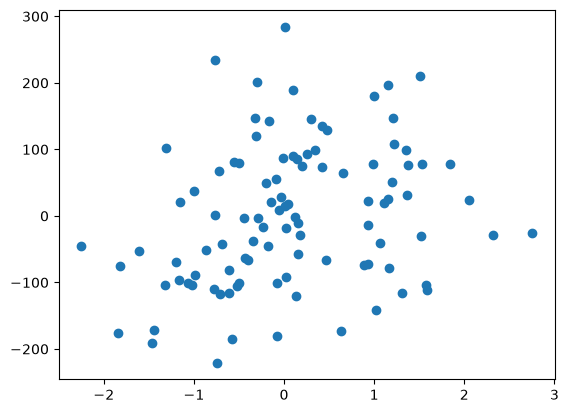

In [19]:
x, y = make_regression(n_samples=100, n_features=2, noise=10)

plt.scatter(x[:, 0], y)

In [20]:
y = y.reshape(y.shape[0], 1)  # Reshape y to be a column vector

In [21]:
# matrice X
X = np.hstack((x, np.ones((x.shape[0], 1))))  # Add a column of ones for the intercept term

print(x.shape, y.shape, X.shape)

(100, 2) (100, 1) (100, 3)


In [22]:
theta = np.random.randn(3, 1)  # Random initialization of theta
theta.shape

(3, 1)

In [23]:
def model(X, theta):
    return X.dot(theta)

model(X, theta)

array([[1.55391782],
       [1.50936459],
       [1.83224796],
       [1.69299432],
       [2.18527912],
       [0.71527275],
       [1.35749034],
       [0.86178974],
       [1.72777571],
       [1.59547315],
       [2.09606848],
       [1.72359738],
       [2.60804318],
       [1.55468622],
       [1.78544335],
       [1.69690675],
       [1.62051216],
       [0.52446946],
       [0.76779689],
       [1.76112435],
       [1.95657183],
       [0.97101595],
       [1.89395313],
       [0.40644849],
       [0.28296565],
       [1.58989459],
       [2.30446317],
       [1.14378192],
       [1.90800652],
       [1.47381541],
       [0.86358894],
       [0.87270479],
       [1.43232774],
       [2.11184439],
       [2.03366134],
       [0.73024336],
       [1.57928065],
       [0.90395397],
       [1.44349037],
       [1.26201138],
       [2.33941182],
       [2.28542544],
       [0.94761681],
       [1.25283684],
       [1.12306252],
       [1.30740947],
       [1.09977195],
       [1.462

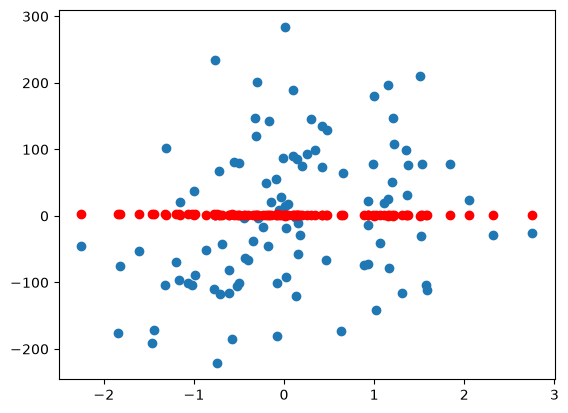

In [24]:
plt.scatter(x[:, 0], y)
plt.scatter(x[:, 0], model(X, theta), color='red')

In [25]:
def cost_function(X, y, theta):
    m = len(y)
    predictions = model(X, theta)
    cost = (1/(2*m)) * np.sum(np.square(predictions - y))
    return cost

In [26]:
cost_function(X, y, theta)

np.float64(5638.045734592202)

In [27]:
def grad(X, y, theta):
    m = len(y)
    return (1/m) * X.T.dot(model(X, theta) - y)

In [28]:
def gradient_descent(X, y, theta, learning_rate=0.01, iterations=1000):
    cost_history = np.zeros(iterations)
    for i in range(iterations):
        theta -= learning_rate * grad(X, y, theta)
        cost_history[i] = cost_function(X, y, theta)

    return theta, cost_history

In [29]:
theta_final, cost_history = gradient_descent(X, y, theta, learning_rate=0.01, iterations=500)

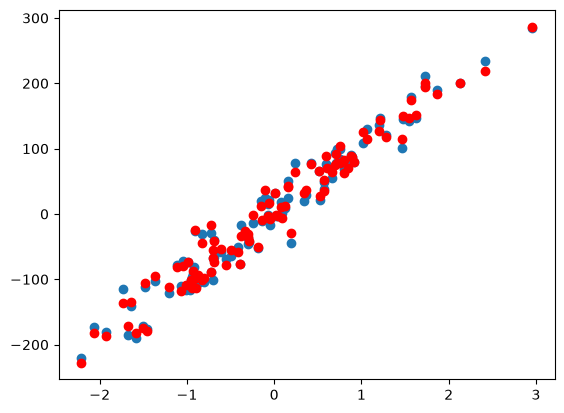

In [30]:
plt.scatter(x[:, 1], y)
plt.scatter(x[:, 1], model(X, theta), color='red')

In [31]:
theta_final

array([[21.84260242],
       [96.36042383],
       [ 1.72614537]])

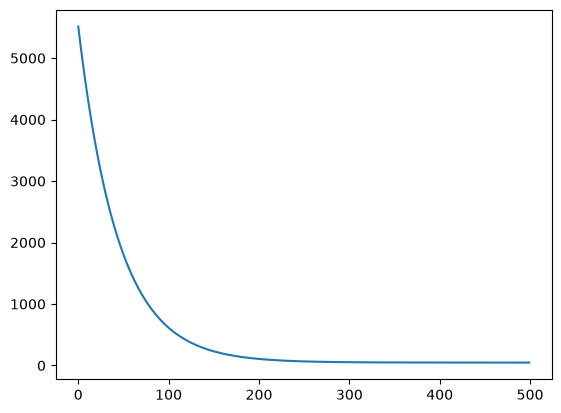

In [32]:
plt.plot(cost_history)

In [33]:
predictions = model(X, theta_final)
r_squared = coef_deter(y, predictions)
r_squared


np.float64(0.9915893110129335)

In [34]:
cost = cost_function(X, y, theta)
cost

np.float64(46.9788153425364)

In [37]:
predictions

array([[ -26.28766399],
       [ -80.67040189],
       [ -55.41963521],
       [  27.2753219 ],
       [-100.90830176],
       [ 103.86042632],
       [  70.86318145],
       [ -25.08036418],
       [ -35.06679067],
       [ -55.80098959],
       [-108.87702541],
       [  -6.13248079],
       [-227.50095564],
       [ -73.81145807],
       [ -67.47139156],
       [-136.75318716],
       [  34.91929635],
       [ 174.54064383],
       [  89.14849177],
       [-134.0311622 ],
       [ -57.56645166],
       [ 150.88440883],
       [ -72.97232048],
       [ 193.66063621],
       [ 200.97166811],
       [  -8.39748806],
       [-113.6432239 ],
       [  87.8535535 ],
       [-111.74953696],
       [  -2.88127167],
       [  91.43106005],
       [ 126.47285555],
       [  63.01653597],
       [-106.591641  ],
       [-100.88437141],
       [ 183.20817339],
       [  -2.17448706],
       [ 114.72513663],
       [   9.94048814],
       [  63.76068061],
       [-171.76119221],
       [ -76.097

In [45]:
fig = px.scatter_3d(
    x=X[:, 0],
    y=X[:, 1],
    z=y[:, 0],
    color_discrete_sequence=['blue'],
    title='Données réelles et prédictions en 3D'
)
fig.add_trace(px.scatter_3d(
    x=X[:, 0],
    y=X[:, 1],
    z=predictions.reshape(-1),
    color_discrete_sequence=['red']
).data[0])
fig.update_traces(marker=dict(size=4))
fig.show()